# 314쪽 연습문제 4번 ~ 9번

## 4.

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns

In [15]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

In [16]:
data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
data3 = data.loc[:,['city_code','gender','waist']]

In [26]:
data3.head()

,city_code,gender,waist
0,36,1,72.1
1,27,2,81.0
2,11,2,70.0
3,31,1,90.8
4,41,2,75.2


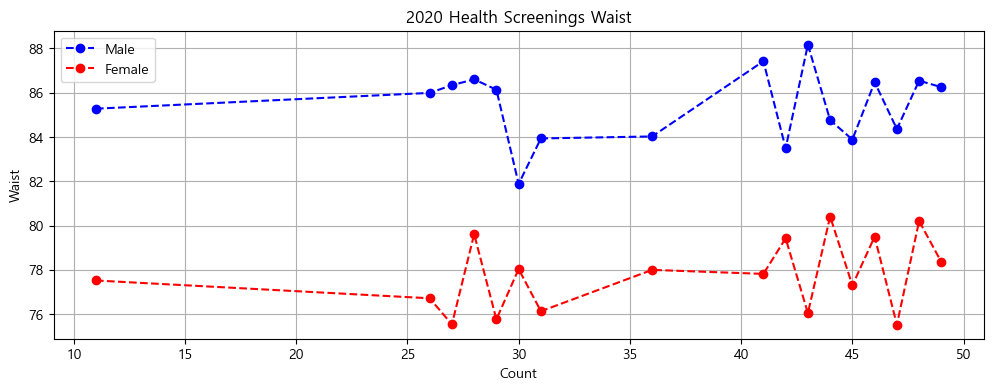

In [17]:
male_data = data3[data3['gender']==1].groupby('city_code')['waist'].mean()
female_data = data3[data3['gender']==2].groupby('city_code')['waist'].mean()

plt.figure(figsize=(12, 4))

plt.plot(male_data, 'bo--', label='Male')
plt.plot(female_data, 'ro--', label='Female')

plt.xlabel('Count')
plt.ylabel('Waist')
plt.title('2020 Health Screenings Waist')
plt.legend()
plt.grid()
plt.show()

## 5.

In [27]:
waistData.head()

,waist
100,65.0
101,76.5
102,99.1
103,74.0
104,71.0


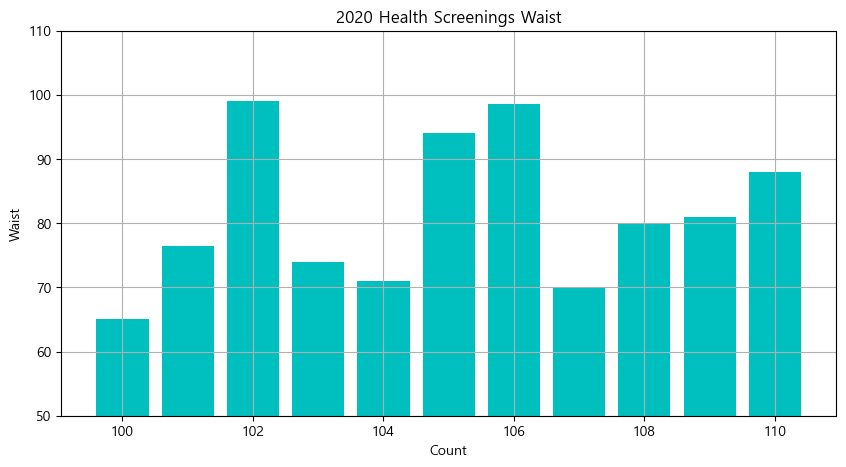

In [ ]:
waistData = data3.loc[100:110,['waist']]

plt.figure(figsize=(10, 5))

# x=인덱스행 height=몸무게
plt.bar(waistData.index, waistData['waist'], color='c')

plt.ylim(50, 110)
plt.xlabel('Count')
plt.ylabel('Waist')
plt.title('2020 Health Screenings Waist')
plt.grid()
plt.show()

## 6. 

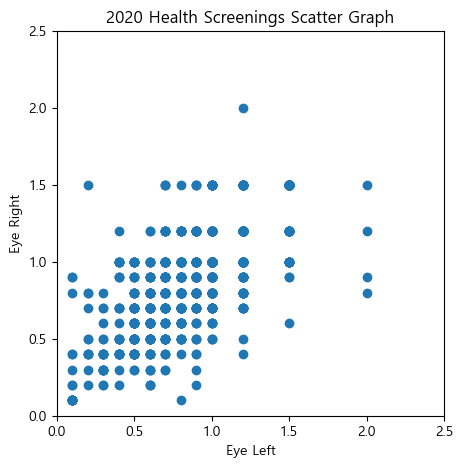

In [19]:
lEyeData = data['eye_left']
rEyeData = data['eye_right']

plt.figure(figsize=(5, 5))

plt.scatter(lEyeData, rEyeData)

plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.xlabel('Eye Left')
plt.ylabel('Eye Right')
plt.title('2020 Health Screenings Scatter Graph')
plt.show()

## 7.

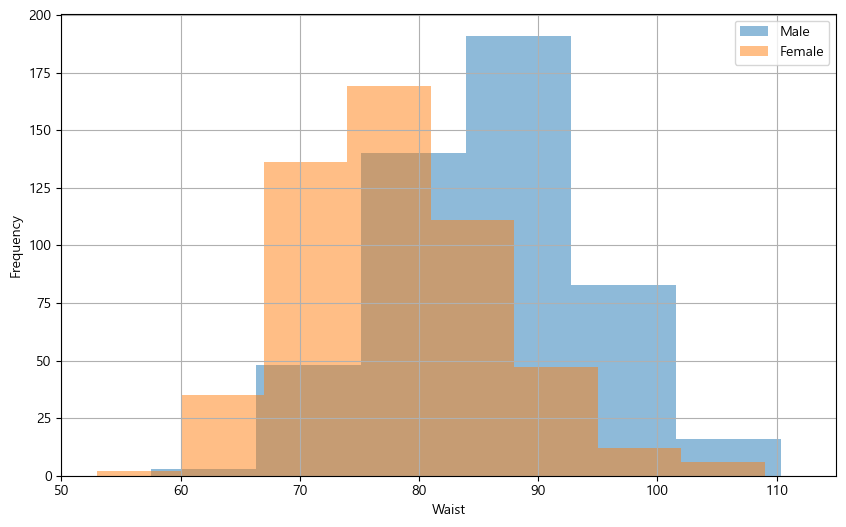

In [20]:
male_data = data3.loc[data3.gender==1, ['gender', 'waist']]
female_data = data3.loc[data3.gender==2, ['gender', 'waist']]

plt.figure(figsize=(10, 6))

plt.hist(male_data['waist'], bins=8, alpha = 0.5, label='Male')
plt.hist(female_data['waist'], bins=8, alpha = 0.5, label='Female')

plt.xlim(50, 115)
plt.xlabel('Waist')
plt.ylabel('Frequency')
plt.legend()
plt.grid()
plt.show()

## 8.

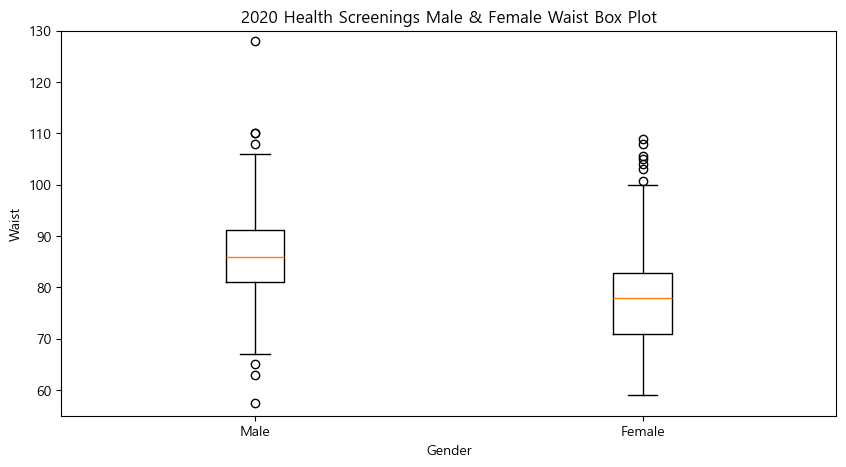

In [21]:
mandata = data3.loc[data3.gender == 1, ['gender', 'waist']]
womandata = data3.loc[data3.gender == 2, ['gender', 'waist']]

male = np.array(mandata['waist'], dtype=object)
female = np.array(womandata['waist'], dtype=object)

plt.figure(figsize=(10, 5))
plt.boxplot([male, female], tick_labels=['Male','Female'])

plt.ylim(55, 130)
plt.xlabel('Gender')
plt.ylabel('Waist')
plt.title('2020 Health Screenings Male & Female Waist Box Plot')
plt.show()

## 9.

In [23]:
data6 = data.loc[:,['gender', 'height', 'weight', 'waist', 'drinking', 'smoking']]

data6['gender'] = data6['gender'].map({1:'Male', 2:'Female'})
data6


,gender,height,weight,waist,drinking,smoking
0,Male,165,60,72.1,0,1
1,Female,150,65,81.0,0,1
2,Female,155,55,70.0,0,1
3,Male,160,70,90.8,0,1
4,Female,155,50,75.2,0,1
...,...,...,...,...,...,...
995,Male,165,70,92.0,1,3
996,Male,165,70,88.0,0,2
997,Female,155,55,80.2,1,1
998,Female,150,55,79.5,0,1


In [25]:
data6['drinking'] = data6['drinking'].map({0:'Non-drinking', 1:'Drinking'})

In [28]:
data6['smoking']

0      1
1      1
2      1
3      1
4      1
      ..
995    3
996    2
997    1
998    1
999    2
Name: smoking, Length: 1000, dtype: int64

In [29]:
data6['smoking'] = data6['smoking'].map({1:'Non-smoking', 2:'Non-smoking', 3:'Smoking'})

In [30]:
smoking = data6.groupby(['gender','smoking'])['smoking'].count()
smoking = smoking.to_frame(name='count')
smoking = smoking.reset_index()

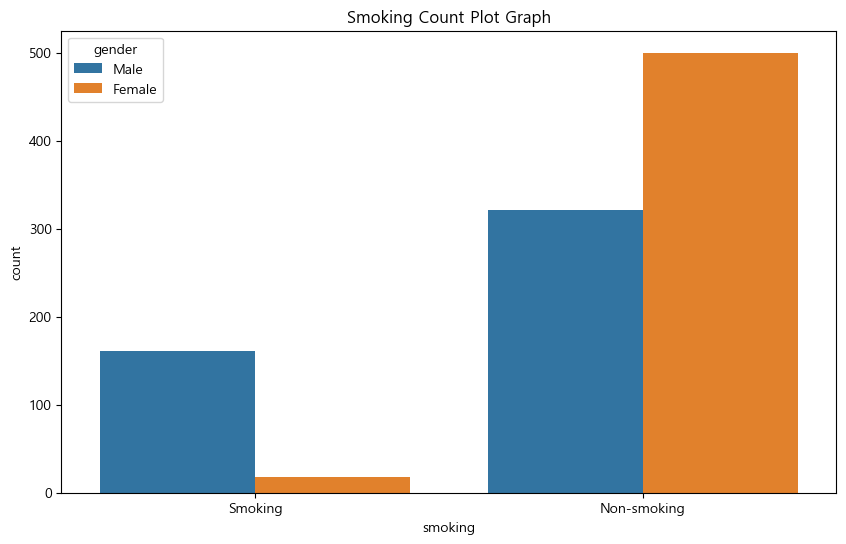

In [31]:
plt.figure(figsize=(10,6))

sns.countplot(data=data6, x='smoking', hue='gender', order=['Smoking','Non-smoking'])

plt.title('Smoking Count Plot Graph')
plt.show()